In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error, median_absolute_error

import time
import warnings
# Suppress the SettingWithCopyWarning
warnings.filterwarnings("ignore")

In [3]:
#import excel dataset
df = pd.read_excel('/content/drive/My Drive/Colab Notebooks/Datasets/Dataset.xlsx', sheet_name='Included Cases')

In [4]:
df.head()

,Tenant,Entity ID,Date of Surgery,Pt Age,Pt Gender,Supplemental Procedures,Laterality,Procedure Subtype,Primary Incision Meridian,Surgeon SIA,...,MFR Constant Deviation from Predicted SE,Opt Constant Deviation from Predicted SE,Absolute Value of MFR Constant Deviation from Predicted SE,Absolute Value of Opt Constant Deviation from Predicted SE,MFR witihin 0.25,MFR within 0.50,MFR within 1.00,OPT within 0.25,OPT within 0.50,OPT within 1.00
0,aljgk,iniXCt70,2020-08-10,52,MALE,None,OS,Femtosecond laser,0,0.12,...,-0.815,-0.555,0.815,0.555,No,No,Yes,No,No,Yes
1,aljgk,iniXCt52,2020-08-10,52,MALE,None,OD,Femtosecond laser,180,0.12,...,0.995,1.255,0.995,1.255,No,No,Yes,No,No,No
2,aljgk,cR5QZt112,2021-12-02,72,FEMALE,None,OD,Standard Phaco,180,0.10,...,-0.385,-0.195,0.385,0.195,No,Yes,Yes,Yes,Yes,Yes
3,aljgk,AMjPct220,2021-03-02,68,MALE,None,OS,Standard Phaco,20,0.10,...,-0.710,-0.580,0.710,0.580,No,No,Yes,No,No,Yes
4,aljgk,hQijLt505,2021-10-07,62,FEMALE,None,OS,Standard Phaco,20,0.10,...,0.235,0.395,0.235,0.395,Yes,Yes,Yes,No,Yes,Yes


In [5]:
df.columns

Index(['Tenant', 'Entity ID', 'Date of Surgery', 'Pt Age', 'Pt Gender',
       'Supplemental Procedures', 'Laterality', 'Procedure Subtype',
       'Primary Incision Meridian', 'Surgeon SIA', 'KCN?', 'AL', 'AL Source',
       'WTW', 'ACD', 'LT', 'CCT', 'Biometer Used', 'Selected AK Steep K',
       'Selected AK Steep K Axis', 'Selected AK Flat K',
       'Selected AK Flat K Axis', 'Selected AK Device', 'IOL Model',
       'IOL Power', 'Manufacturer A-Constant', 'BUII Optimized Constant',
       'Current (pre-op) refraction SE', 'IOLMaster AntK Steep K',
       'IOLMaster AntK Steep K Axis', 'IOLMaster AntK Flat K',
       'IOLMaster AntK Flat K Axis', 'IOLMaster PostK Steep K',
       'IOLMaster PostK Steep K Axis', 'IOLMaster PostK Flat K',
       'IOLMaster PostK Flat K Axis', 'IOLMaster 700 TK Steep K',
       'IOLMaster 700 TK Steep K Axis', 'IOLMaster 700 TK Flat K',
       'IOLMaster 700 TK Flat K Axis', 'Post-op Refraction Date',
       'Post-op Refraction Method', 'Post-op Sphe

In [6]:
df.shape

(23604, 66)

**most_important_features** is an array with the features highlighted by Dr. Pellegrini,<br> in addition, by technical choice,
I would like to investigate whether the age and gender <br> of the patients can influence in any way the predictions.

In [7]:
most_important_features = ['Pt Age', 'Pt Gender','IOL Model','AL','WTW','ACD', 'LT', 'CCT', 'Selected AK Steep K', 'Selected AK Flat K', 'IOL Power', 'Manufacturer A-Constant', 'Post-op SE']

In [8]:
df[most_important_features]

,Pt Age,Pt Gender,IOL Model,AL,WTW,ACD,LT,CCT,Selected AK Steep K,Selected AK Flat K,IOL Power,Manufacturer A-Constant,Post-op SE
0,52,MALE,Tecnis ZCB00,23.2327,12.6714,3.33569,4.30074,529.828162,44.3520,43.6090,25.5,119.3,-1.625
1,52,MALE,Tecnis ZCB00,23.3274,12.5529,3.37018,4.30183,480.093783,41.8580,40.3420,26.5,119.3,-2.375
2,72,FEMALE,Clareon CNA0T0,24.2646,12.2676,3.39447,4.71806,452.065408,44.4430,44.0570,18.5,119.1,0.125
3,68,MALE,Tecnis ZCB00,25.0171,12.3181,3.67934,4.64718,549.986899,45.8852,44.9453,15.0,119.3,0.000
4,62,FEMALE,Tecnis DCB00,24.2141,11.9185,3.20780,3.85639,537.917972,44.9596,43.8037,18.0,119.3,-0.375
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23599,72,MALE,enVista MX60E,23.2437,11.6950,2.87651,4.84678,585.916579,45.1431,44.9433,21.0,119.1,0.000
23600,63,FEMALE,enVista MX60E,23.7383,11.4576,3.37300,4.22513,566.995025,46.2076,45.6233,18.0,119.1,-0.500
23601,84,MALE,enVista MX60E,23.1704,11.2837,3.02549,4.82084,546.886802,46.6142,46.0880,19.5,119.1,0.000
23602,63,UNKNOWN,enVista MX60E,25.1789,11.8890,3.72592,4.28713,615.295410,44.3184,43.8395,16.5,119.1,0.000


In [12]:
# Common statistics about the data
df[most_important_features].describe()

,Pt Age,AL,WTW,ACD,LT,CCT,Selected AK Steep K,Selected AK Flat K,IOL Power,Manufacturer A-Constant,Post-op SE
count,23604.000000,23604.000000,23604.000000,23604.000000,23604.000000,23604.000000,23604.000000,23604.000000,23604.000000,23604.000000,23604.000000
mean,71.024572,23.947357,12.016503,3.169279,4.630564,553.700979,44.407554,43.554264,20.031637,118.926864,-0.325745
std,8.268755,1.275398,0.414940,0.389467,0.430280,37.206947,1.614049,1.574420,3.652410,0.276044,0.858515
min,0.000000,19.605900,9.540480,1.304090,1.200810,0.445206,36.001900,13.190000,-6.000000,117.700000,-62.000000
25%,66.000000,23.115700,11.740450,2.904400,4.347400,529.569506,43.327975,42.524325,18.500000,118.700000,-0.500000
50%,72.000000,23.791850,12.011700,3.164315,4.638610,553.596535,44.365250,43.540000,20.500000,118.900000,-0.125000
75%,76.000000,24.600850,12.291025,3.432450,4.915773,577.892661,45.431350,44.569600,22.500000,119.100000,0.125000
max,101.000000,35.195100,14.481800,4.890000,7.881670,725.563288,58.653200,54.661100,37.000000,119.600000,9.000000


Text(0.5, 1.0, 'Correlation Matrix')

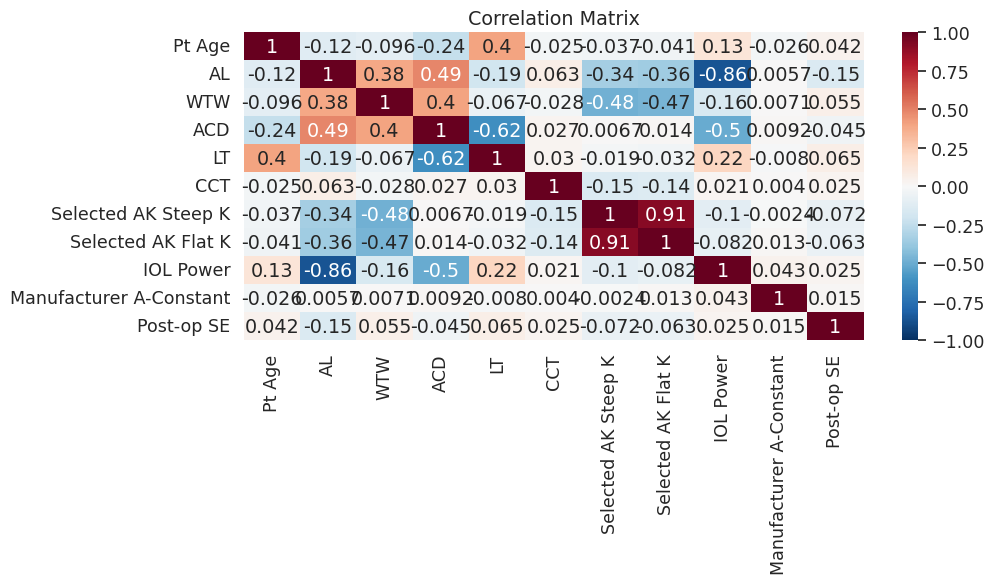

In [11]:
 # plot correleation between features
sns.set(font_scale=1.15)
plt.figure(figsize=(10,4))
sns.heatmap(
    df[most_important_features].corr(),
    cmap='RdBu_r',
    annot=True,
    vmin=-1, vmax=1);
plt.title("Correlation Matrix")

# Dott. Pellegrini's suggestions
* Take the mean of *Selected AK Flat K* and *Selected AK Steep K*
* Do not consider *BUII Optimized Constant*
* Consider the most frequent IOL models

In [13]:
#finding null values
data = df[most_important_features]
print(data.isnull().sum())

Pt Age                     0
Pt Gender                  0
IOL Model                  0
AL                         0
WTW                        0
ACD                        0
LT                         0
CCT                        0
Selected AK Steep K        0
Selected AK Flat K         0
IOL Power                  0
Manufacturer A-Constant    0
Post-op SE                 0
dtype: int64


In [14]:
# As we can see in the correlation matrix, these two features are highly correlated.
# Therefore, we take their mean to reduce dimensionality
data.loc[:,'Selected AK mean'] = (data['Selected AK Flat K']+ data['Selected AK Steep K'])/2

In [15]:
# New feature
data['Selected AK mean']

0        43.98050
1        41.10000
2        44.25000
3        45.41525
4        44.38165
           ...   
23599    45.04320
23600    45.91545
23601    46.35110
23602    44.07895
23603    44.96920
Name: Selected AK mean, Length: 23604, dtype: float64

In [16]:
# Drop old features
columns_to_drop = ['Selected AK Flat K', 'Selected AK Steep K']
data.drop(columns_to_drop, axis = 1, inplace = True )

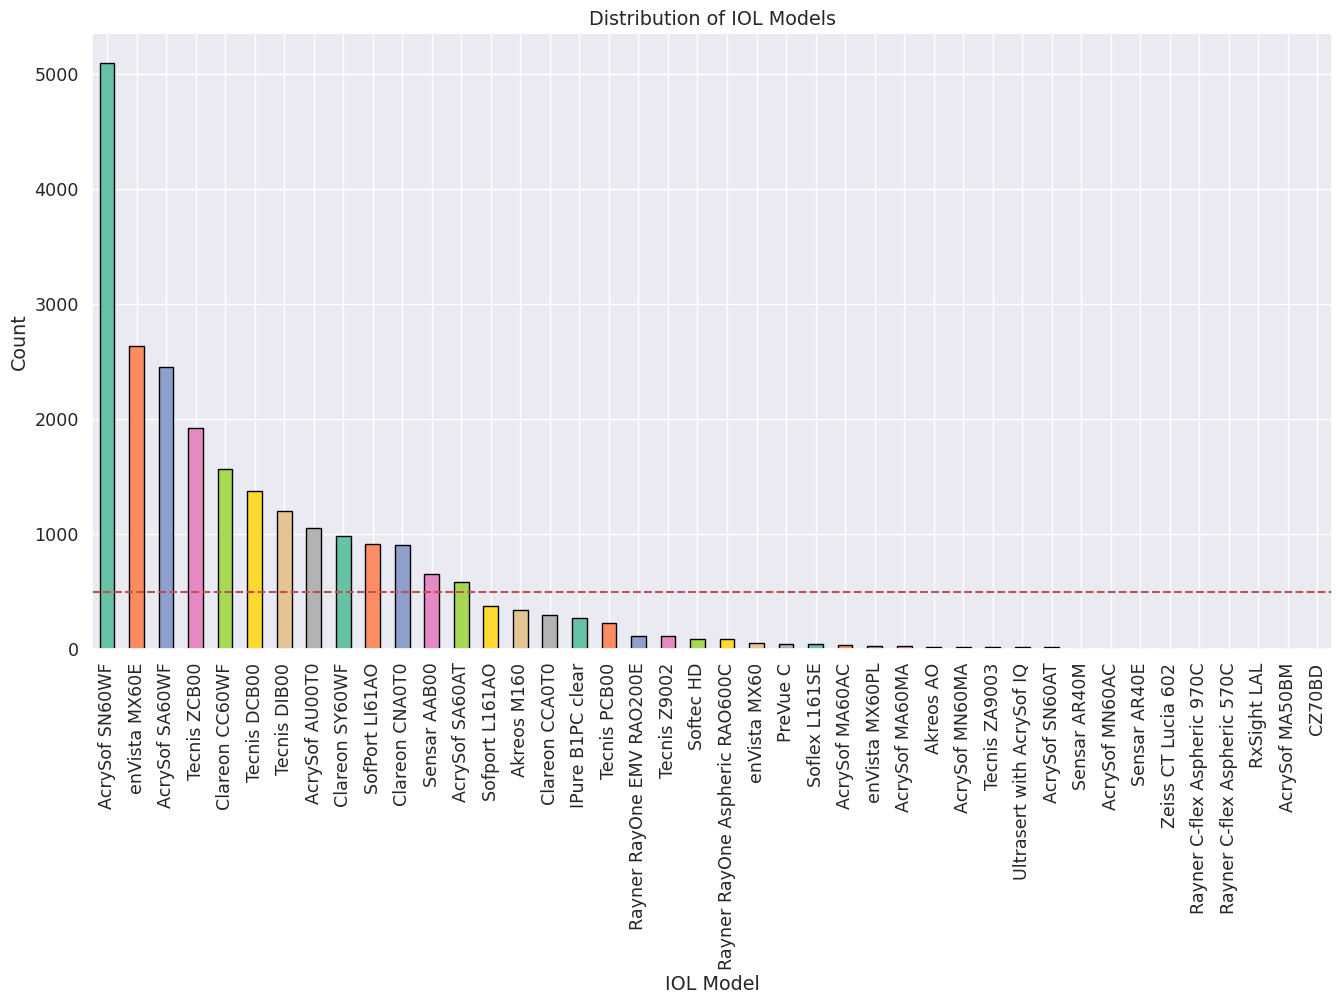

In [17]:
# Display the frequency distribution of IOL models.
data['IOL Model'].value_counts().plot(kind = 'bar', figsize=(16,8), edgecolor='black', color=sns.color_palette('Set2')
                                      , xlabel = 'IOL Model', ylabel = 'Count', title = 'Distribution of IOL Models')
plt.axhline(y=500, color='r', linestyle='--')

# Studying the case of including the features *Pt Age* and *Pt Gender*

In [18]:
data.head()

,Pt Age,Pt Gender,IOL Model,AL,WTW,ACD,LT,CCT,IOL Power,Manufacturer A-Constant,Post-op SE,Selected AK mean
0,52,MALE,Tecnis ZCB00,23.2327,12.6714,3.33569,4.30074,529.828162,25.5,119.3,-1.625,43.98050
1,52,MALE,Tecnis ZCB00,23.3274,12.5529,3.37018,4.30183,480.093783,26.5,119.3,-2.375,41.10000
2,72,FEMALE,Clareon CNA0T0,24.2646,12.2676,3.39447,4.71806,452.065408,18.5,119.1,0.125,44.25000
3,68,MALE,Tecnis ZCB00,25.0171,12.3181,3.67934,4.64718,549.986899,15.0,119.3,0.000,45.41525
4,62,FEMALE,Tecnis DCB00,24.2141,11.9185,3.20780,3.85639,537.917972,18.0,119.3,-0.375,44.38165


# *Pt Gender* Unknown values

In this section, we expect to find values such as male or female,<br> the appearance of an unexpected third value can be handled by: <br>
1. removing the Unknown samples <br>
2. adding them to the majority class, in our case female <br>
3. treating them as a separate category."

Text(0.5, 1.0, 'Gender distribution')

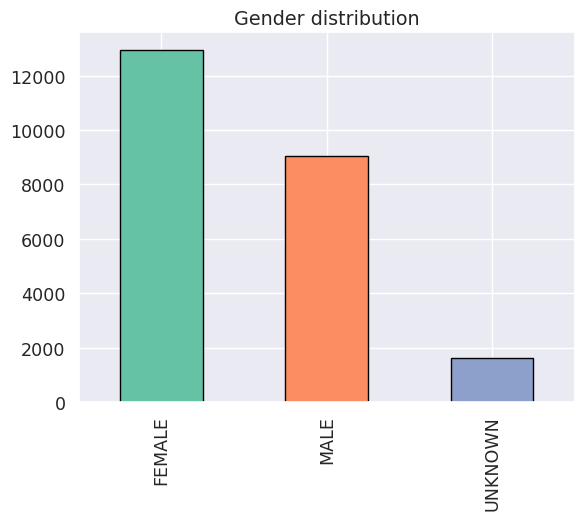

In [21]:
# We consider the option 3
data['Pt Gender'].value_counts().plot(kind='bar', edgecolor='black', color=sns.color_palette('Set2'))
plt.title("Gender distribution")

In [17]:
# Generate a categorical feature from 'Pt Age' to summarize age info
age_interval = [0,40, 65, 100]
labels = ['young', 'middle', 'old']
data['Age_category'] = pd.cut(data['Pt Age'], bins=age_interval, labels=labels, right=False)
print(data['Age_category'])

0        middle
1        middle
2           old
3           old
4        middle
          ...  
23599       old
23600    middle
23601       old
23602    middle
23603       old
Name: Age_category, Length: 23604, dtype: category
Categories (3, object): ['young' < 'middle' < 'old']


Text(0.5, 1.0, 'Age_category distribution')

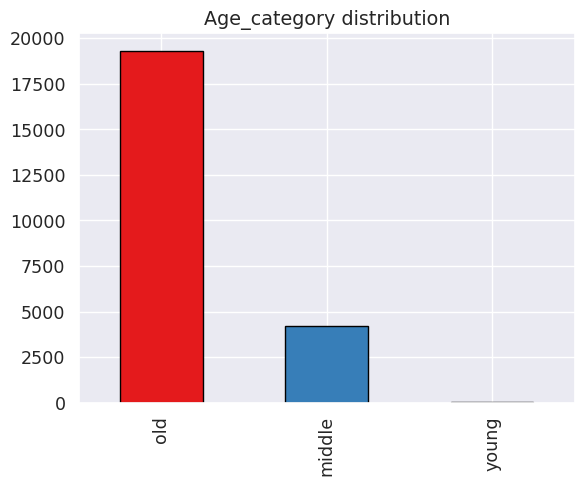

In [18]:
data['Age_category'].value_counts().plot(kind='bar', edgecolor='black', color=sns.color_palette('Set1'))
plt.title("Age_category distribution")

In [19]:
#remove old column Pt Age
data.drop('Pt Age', axis = 1, inplace = True)
# convert categorical data to 1-hot-encoding
data = pd.get_dummies(data, columns=['Pt Gender','Age_category'])

In [20]:
data

,IOL Model,AL,WTW,ACD,LT,CCT,IOL Power,Manufacturer A-Constant,Post-op SE,Selected AK mean,Pt Gender_FEMALE,Pt Gender_MALE,Pt Gender_UNKNOWN,Age_category_young,Age_category_middle,Age_category_old
0,Tecnis ZCB00,23.2327,12.6714,3.33569,4.30074,529.828162,25.5,119.3,-1.625,43.98050,0,1,0,0,1,0
1,Tecnis ZCB00,23.3274,12.5529,3.37018,4.30183,480.093783,26.5,119.3,-2.375,41.10000,0,1,0,0,1,0
2,Clareon CNA0T0,24.2646,12.2676,3.39447,4.71806,452.065408,18.5,119.1,0.125,44.25000,1,0,0,0,0,1
3,Tecnis ZCB00,25.0171,12.3181,3.67934,4.64718,549.986899,15.0,119.3,0.000,45.41525,0,1,0,0,0,1
4,Tecnis DCB00,24.2141,11.9185,3.20780,3.85639,537.917972,18.0,119.3,-0.375,44.38165,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23599,enVista MX60E,23.2437,11.6950,2.87651,4.84678,585.916579,21.0,119.1,0.000,45.04320,0,1,0,0,0,1
23600,enVista MX60E,23.7383,11.4576,3.37300,4.22513,566.995025,18.0,119.1,-0.500,45.91545,1,0,0,0,1,0
23601,enVista MX60E,23.1704,11.2837,3.02549,4.82084,546.886802,19.5,119.1,0.000,46.35110,0,1,0,0,0,1
23602,enVista MX60E,25.1789,11.8890,3.72592,4.28713,615.295410,16.5,119.1,0.000,44.07895,0,0,1,0,1,0


# Separation of the 8 training sets
1. The first, with all IOL models and the addition of Age_category & Gender
2. The second, with the most frequent IOL models and the addition of Age_category & Gender
3. The third, with all IOL models
4. The fourth, with the most frequent IOL models
5. The fifth, with all IOL models, but dropping the feature *IOL Model*
6. The sixth, with the most frequent models, but after models selection we drop the feature *IOL Model*
7. The seventh,  with all IOL models, but dropping the feature *IOL Power*
8. The eighth, with the most frequent models, but after models selection we drop the feature *IOL Power*

In [21]:
#counts[counts > 500].index

I am looking to see if there is an IOL Model in the dataset belonging to the list <br> of those with a frequency greater than 500.

In [22]:
# IOL models frequencies
counts = data['IOL Model'].value_counts()
# Select only data with IOL models frequencies greater then 500.
filtered_data = data[data['IOL Model'].isin(counts[counts > 500].index)]

In [23]:
filtered_data

,IOL Model,AL,WTW,ACD,LT,CCT,IOL Power,Manufacturer A-Constant,Post-op SE,Selected AK mean,Pt Gender_FEMALE,Pt Gender_MALE,Pt Gender_UNKNOWN,Age_category_young,Age_category_middle,Age_category_old
0,Tecnis ZCB00,23.2327,12.6714,3.33569,4.30074,529.828162,25.5,119.3,-1.625,43.98050,0,1,0,0,1,0
1,Tecnis ZCB00,23.3274,12.5529,3.37018,4.30183,480.093783,26.5,119.3,-2.375,41.10000,0,1,0,0,1,0
2,Clareon CNA0T0,24.2646,12.2676,3.39447,4.71806,452.065408,18.5,119.1,0.125,44.25000,1,0,0,0,0,1
3,Tecnis ZCB00,25.0171,12.3181,3.67934,4.64718,549.986899,15.0,119.3,0.000,45.41525,0,1,0,0,0,1
4,Tecnis DCB00,24.2141,11.9185,3.20780,3.85639,537.917972,18.0,119.3,-0.375,44.38165,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23599,enVista MX60E,23.2437,11.6950,2.87651,4.84678,585.916579,21.0,119.1,0.000,45.04320,0,1,0,0,0,1
23600,enVista MX60E,23.7383,11.4576,3.37300,4.22513,566.995025,18.0,119.1,-0.500,45.91545,1,0,0,0,1,0
23601,enVista MX60E,23.1704,11.2837,3.02549,4.82084,546.886802,19.5,119.1,0.000,46.35110,0,1,0,0,0,1
23602,enVista MX60E,25.1789,11.8890,3.72592,4.28713,615.295410,16.5,119.1,0.000,44.07895,0,0,1,0,1,0


<Axes: title={'center': 'Distribution of most frequent IOL Models'}, xlabel='IOL Model', ylabel='Count'>

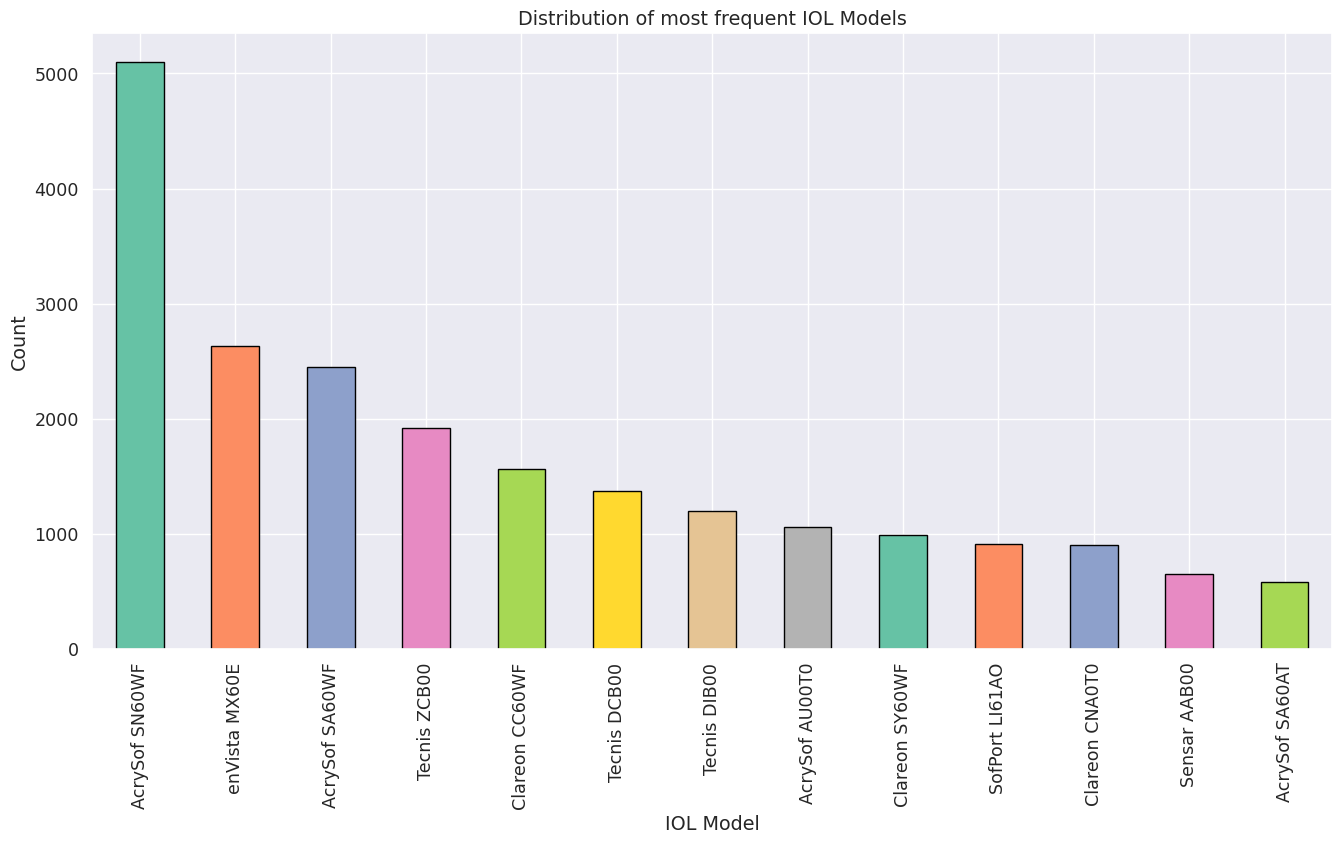

In [24]:
# Display the most frequent distribution of IOL models.
filtered_data['IOL Model'].value_counts().plot(kind = 'bar', figsize=(16,8), edgecolor='black', color=sns.color_palette('Set2')
                                      , xlabel = 'IOL Model', ylabel = 'Count', title = 'Distribution of most frequent IOL Models')

In [25]:
# Contains features highlighted plus Age and Gender
data.columns

Index(['IOL Model', 'AL', 'WTW', 'ACD', 'LT', 'CCT', 'IOL Power',
       'Manufacturer A-Constant', 'Post-op SE', 'Selected AK mean',
       'Pt Gender_FEMALE', 'Pt Gender_MALE', 'Pt Gender_UNKNOWN',
       'Age_category_young', 'Age_category_middle', 'Age_category_old'],
      dtype='object')

In [26]:
# Contains features highlighted plus Age and Gender, filtered by IOL models frequencies
filtered_data.columns

Index(['IOL Model', 'AL', 'WTW', 'ACD', 'LT', 'CCT', 'IOL Power',
       'Manufacturer A-Constant', 'Post-op SE', 'Selected AK mean',
       'Pt Gender_FEMALE', 'Pt Gender_MALE', 'Pt Gender_UNKNOWN',
       'Age_category_young', 'Age_category_middle', 'Age_category_old'],
      dtype='object')

In [27]:
# Contains only features highlighted
no_extra_feature_data = data[['IOL Model','AL','WTW','ACD', 'LT', 'CCT', 'Selected AK mean', 'IOL Power', 'Manufacturer A-Constant', 'Post-op SE']]

In [28]:
# Contains only features highlighted filtered by IOL models frequencies
no_extra_feature_filtered_data = filtered_data[['IOL Model','AL','WTW','ACD', 'LT', 'CCT', 'Selected AK mean', 'IOL Power', 'Manufacturer A-Constant', 'Post-op SE']]

In [29]:
# Contains only features highlighted without 'IOL Model'
no_category_data = data[['AL','WTW','ACD', 'LT', 'CCT', 'Selected AK mean', 'IOL Power', 'Manufacturer A-Constant', 'Post-op SE']]

In [30]:
# Contains only features highlighted filtered by IOL models frequencies without 'IOL Model'
no_category_filtered_data = filtered_data[['AL','WTW','ACD', 'LT', 'CCT', 'Selected AK mean', 'IOL Power', 'Manufacturer A-Constant', 'Post-op SE']]

In [31]:
# Contains only features highlighted without 'IOL Model' and 'IOL Power', Remember that IOL Power is high negative correlated with 'AL'
no_IOL_power_data = no_extra_feature_data.drop(['IOL Power'], axis = 1)

In [32]:
# Contains only features highlighted filtered by IOL models frequencies without 'IOL Model' and 'IOL Power'
no_IOL_power_filtered_data = no_extra_feature_filtered_data.drop(['IOL Power'], axis = 1)

In [33]:
# Define a dictionary with all eight training sets, as we introduced before.
datasets = { "all_IOL_models_with_age_gender" : data, "best_IOL_models_with_age_gender":filtered_data ,
            "all_IOL_models": no_extra_feature_data, "best_IOL_models": no_extra_feature_filtered_data,
             "all_IOL_models_no_cat" : no_category_data, "best_IOL_models_no_cat" : no_category_filtered_data,
             "all_IOL_models_no_IOL_Power": no_IOL_power_data, "best_IOL_models_no_IOL_Power" : no_IOL_power_filtered_data,
             }

# Run experiments on eight different set of data

The paper, An empirical study on hyperparameter tuning of decision trees [5] also states that the ideal **min_samples_leaf** values tend to be between 1 to 20 for the CART algorithm

According to the paper, An empirical study on hyperparameter tuning of decision trees [5] the ideal **min_samples_split** values tend to be between 1 to 40 for the CART algorithm

[5] *Rafael Gomes Mantovani, Tomáš Horváth, Ricardo Cerri, Sylvio Barbon Junior, Joaquin Vanschoren, André Carlos Ponce de Leon Ferreira de Carvalho, “An empirical study on hyperparameter tuning of decision trees”*


In [37]:
# Define a DataFrame only for save important info about experiments
resume_experiment = pd.DataFrame(columns=['model_name', 'model_type','dataset_shape',
                                          'training_samples', 'test_samples', 'training_time', 'mse','mae','medae'])
# Run Experiments
for key,dataset in datasets.items():
  #initialize timer
  start = None
  #encoded IOL model with 1-hot-encoding
  if 'IOL Model' in dataset.columns:
    dataset = pd.get_dummies(dataset, columns=['IOL Model'])
  #Splitting dataset into X and y
  y = dataset['Post-op SE']
  X = dataset.drop(['Post-op SE'], axis = 1)


  print("Computing dataset :",key)
  print("Dataset shape: ", dataset.shape)

  # store dataset
  dataset.to_csv('/content/drive/My Drive/Colab Notebooks/Datasets/project_work_ml/'+key+'.csv', index = False)
  # generate split into training set and test set
  x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=10) #random_state set to a unique value to ensure code reproducibility

  # store training_set and test_set
  training_set = pd.DataFrame(x_train.copy(), columns = x_train.columns)
  training_set['Post-op SE'] = y_train
  test_set =  pd.DataFrame(x_test.copy(), columns = x_test.columns)
  test_set['Post-op SE'] = y_test
  training_set.to_csv('/content/drive/My Drive/Colab Notebooks/Datasets/project_work_ml/training_set/'+key+'.csv', index = False)
  test_set.to_csv('/content/drive/My Drive/Colab Notebooks/Datasets/project_work_ml/test_set/'+key+'.csv', index = False)

  print("n° of Training samples: ", len(y_train))
  print("n° of Test samples: ", len(y_test))
  #################################################### DT ###############################################
  # define hyperparameters
  param_dtr = {
      'criterion': ['mse', 'friedman_mse', 'mae'],  # Splitting criterion, “friedman_mse” uses mean squared error with Friedman’s improvement score for potential splits
      'splitter': ['best', 'random'],  # Strategy to choose the split at each node
      'max_depth': [None, 3, 5, 10 , 20, 30],  # Maximum depth of the tree
      'min_samples_split': [2, 5, 10, 20, 30, 40],  # Minimum number of samples required to split an internal node
      'min_samples_leaf': [1, 2, 5, 10, 20],  # Minimum number of samples required to be at a leaf node
      'max_features': [None,"auto", 'sqrt', 'log2'],  # Number of features to consider for the best split
      'max_leaf_nodes': [None, 50, 100, 200],  # Values for max leaf nodes
      'min_weight_fraction_leaf': [0.0, 0.1, 0.2], # This parameter controls the minimum weighted fraction of the sum total of weights (of all the input samples) required to be at a leaf node. It is used to control overfitting. A small value may encourage more splits.
      'min_impurity_decrease':[0.0, 0.1, 0.2], # A node will be split if this split induces a decrease of the impurity greater than or equal to this value.
      'ccp_alpha' : [0.0, 0.01, 0.001, 0.1], # This parameter is used for Minimal Cost-Complexity Pruning (CCP). It is the complexity parameter used for Minimal Cost-Complexity Pruning. Larger values increase the amount of pruning.
      'random_state' : [10] # Controls the randomness of the estimator.
      }
  # define the model
  dtr_model = DecisionTreeRegressor()
  # Apply RandomizedSearchCV to DecisioTreeRegressor
  rand_search_dtr = RandomizedSearchCV(dtr_model, param_dtr, cv=5, scoring='neg_mean_squared_error', random_state = 10) #random_state set to a unique value to ensure code reproducibility
  # initialize timer
  start = time.time()
  # fit the model
  rand_search_dtr.fit(x_train, y_train)
  # calculate elapsed time
  elapsed_time = time.time() - start
  elapsed_time = np.round(elapsed_time,3)
  # Print the best parameters
  print("\n")
  print("DTR Training time (sec) : ", elapsed_time)
  print("DTR Best Parameters: ", rand_search_dtr.best_params_)
  # calculate predictions of DecisionTreeRegressor model
  y_pred_dtr = rand_search_dtr.predict(x_test)

  #calculate metrics for estimating errors
  MSE = mean_squared_error(y_test,y_pred_dtr)
  MAE = mean_absolute_error(y_test,y_pred_dtr)
  MedAE = median_absolute_error(y_test, y_pred_dtr)
  # Print metrics for DecisionTreeRegressor
  print("DTR mean_squared_error : %.2f%%" % (MSE * 100))
  print("DTR mean_absolute_error : %.2f%%" % (MAE * 100))
  print("DTR median_absolute_error : %.2f%%" % (MedAE * 100))
  print("\n")

  # append a row to resume_experiment DataFrame
  resume_experiment = resume_experiment.append({'model_name': key, 'model_type': "DT", 'dataset_shape (rows, columns)': dataset.shape, 'training_samples': len(y_train),
              'test_samples': len(y_test), **rand_search_dtr.best_params_,
              'training_time (sec)': elapsed_time, 'mse': MSE, 'mae': MAE, 'medae': MedAE}, ignore_index=True)

  #################################################### RF ###############################################
  # define hyperparameters
  param_rfr = {
        'n_estimators': [50, 100, 200], # Number of trees in the forest
        'criterion': ['mse', 'friedman_mse', 'mae'],  # Splitting criterion
        'max_depth': [None, 3, 5, 10 , 20, 30],  # Maximum depth of the tree
        'min_samples_split': [2, 5, 10, 20, 30, 40],  # Minimum number of samples required to split an internal node
        'min_samples_leaf': [1, 2, 5, 10, 20],  # Minimum number of samples required to be at a leaf node
        'max_features': [None,"auto", 'sqrt', 'log2'],  # Number of features to consider for the best split
        'max_leaf_nodes': [None, 50, 100, 200],  # Values for max leaf nodes
        'min_impurity_decrease': [0.0, 0.1, 0.2], # A node will be split if this split induces a decrease of the impurity greater than or equal to this value.
        'ccp_alpha' :  [0.0, 0.01, 0.001, 0.1], # Complexity parameter used for Minimal Cost-Complexity Pruning.
        'bootstrap' : [False, True], # Whether bootstrap samples are used when building trees
        'oob_score' : [False, True], # Whether to use out-of-bag samples to estimate the generalization score.
        'warm_start': [False, True], # When set to True, reuse the solution of the previous call to fit and add more estimators to the ensemble, otherwise, just fit a whole new forest.
        'random_state' : [10] # Controls both the randomness of the bootstrapping and the sampling of the features to consider when looking for the best split at each node
        }

  # define the model
  rfr_model = RandomForestRegressor()
  # Apply RandomizedGridSearch to RandomForestRegressor
  rand_search_rfr = RandomizedSearchCV(rfr_model, param_rfr, cv=5, scoring='neg_mean_squared_error', random_state=10) #random_state set to a unique value to ensure code reproducibility
  # initialize timer
  start = time.time()
  # fit the model
  rand_search_rfr.fit(x_train, y_train)
  # calculate elapsed time
  elapsed_time = time.time() - start
  elapsed_time = np.round(elapsed_time,3)
  print("RFR Training time (sec) : ", elapsed_time)

  # calculate predictions of RandomForestRegressor model
  y_pred_rfr = rand_search_rfr.predict(x_test)
  # Print the best parameters for RandomForestRegressor
  print("RFR Best Parameters: ", rand_search_rfr.best_params_)
  #calculate metrics for estimating errors
  MSE = mean_squared_error(y_test,y_pred_rfr)
  MAE = mean_absolute_error(y_test,y_pred_rfr)
  MedAE = median_absolute_error(y_test, y_pred_rfr)
  # Print metrics for RandomForestRegressor
  print("RFR mean_squared_error : %.2f%%" % (MSE * 100))
  print("RFR mean_absolute_error : %.2f%%" % (MAE * 100))
  print("RFR median_absolute_error : %.2f%%" % (MedAE * 100))
  print("\n")
  print("#######################################################")
  print("\n")

  # append a row to resume_experiment DataFrame
  resume_experiment = resume_experiment.append({'model_name': key, 'model_type': "RF",'dataset_shape (rows,columns)': dataset.shape, 'training_samples': len(y_train),
              'test_samples': len(y_test), **rand_search_rfr.best_params_,
              'training_time (sec)': elapsed_time, 'mse': MSE, 'mae': MAE, 'medae': MedAE}, ignore_index=True)

# store experiments info
resume_experiment.to_csv('/content/drive/My Drive/Colab Notebooks/Datasets/project_work_ml/resume_exp/resume_experiments.csv', index = False)

Computing dataset : all_IOL_models_with_age_gender
Dataset shape:  (23604, 57)
n° of Training samples:  18883
n° of Test samples:  4721


DTR Training time (sec) :  1.243
DTR Best Parameters:  {'splitter': 'best', 'random_state': 10, 'min_weight_fraction_leaf': 0.1, 'min_samples_split': 40, 'min_samples_leaf': 20, 'min_impurity_decrease': 0.2, 'max_leaf_nodes': 50, 'max_features': 'auto', 'max_depth': 20, 'criterion': 'friedman_mse', 'ccp_alpha': 0.01}
DTR mean_squared_error : 58.96%
DTR mean_absolute_error : 51.47%
DTR median_absolute_error : 35.71%


RFR Training time (sec) :  215.883
RFR Best Parameters:  {'warm_start': True, 'random_state': 10, 'oob_score': False, 'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 2, 'min_impurity_decrease': 0.1, 'max_leaf_nodes': None, 'max_features': None, 'max_depth': None, 'criterion': 'friedman_mse', 'ccp_alpha': 0.0, 'bootstrap': True}
RFR mean_squared_error : 28.69%
RFR mean_absolute_error : 37.31%
RFR median_absolute_error : 

# Best combination found

**Computing dataset : best_IOL_models** <br>
Dataset shape:  (21335, 22)<br>
n° of Training samples:  17068<br>
n° of Test samples:  4267<br>
<br>
DTR Training time (sec) :  0.518 <br>
DTR Best Parameters:  {'splitter': 'best', 'random_state': 10, 'min_weight_fraction_leaf': 0.1, 'min_samples_split': 40, 'min_samples_leaf': 20, 'min_impurity_decrease': 0.2, 'max_leaf_nodes': 50, 'max_features': 'auto', 'max_depth': 20, 'criterion': 'friedman_mse', 'ccp_alpha': 0.01}
<br>
DTR mean_squared_error : 52.45%<br>
DTR mean_absolute_error : 50.35%<br>
DTR median_absolute_error : 34.92%<br>
<br>
<br>
RFR Training time (sec) :  174.256 <br>
RFR Best Parameters:  {'warm_start': True, 'random_state': 10, 'oob_score': False, 'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 2, 'min_impurity_decrease': 0.1, 'max_leaf_nodes': None, 'max_features': None, 'max_depth': None, 'criterion': 'friedman_mse', 'ccp_alpha': 0.0, 'bootstrap': True}
<br>
RFR mean_squared_error : **24.88%** <br>
RFR mean_absolute_error : **36.42%** <br>
RFR median_absolute_error : **27.20%** <br>



